# 09 External Resume Career-Stage Validation

This notebook applies the job-description and incumbent-similarity screening framework to an external Kaggle resume dataset.

The external dataset does **not** contain true age labels, so this notebook does not claim to measure age bias directly. Instead, it extracts **career-stage proxies** from resume text and job titles, including stated years of experience, seniority keywords, and legacy/modern technology signals.

The purpose is to test whether the mechanism from the synthetic experiments is directionally visible on real resume text:

- **Job-description similarity:** Does the resume match the stated role requirements?
- **Incumbent-profile similarity:** Does the resume resemble the synthetic reference employee population from Notebook 08?

Because career stage is inferred and noisy, this notebook should be treated as an external validation / robustness check rather than primary evidence.

## Expected input file

Save the Kaggle file as:

```text
data/external/resume_dataset.csv
```

Recommended shell commands from the repository root:

```bash
mkdir -p data/external
cp /path/to/resume_dataset.csv data/external/resume_dataset.csv
```

The notebook expects the CSV to contain columns similar to:

```text
category, job_title, Text
```

In [1]:
from __future__ import annotations

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics.pairwise import cosine_similarity

try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise ImportError(
        "sentence-transformers is required. Install with: pip install sentence-transformers"
    ) from exc

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
EXTERNAL_DIR = DATA_DIR / "external"
EXPERIMENTS_DIR = DATA_DIR / "experiments"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = EXTERNAL_DIR / "resume_dataset.csv"

AGE_STAGE_ORDER = [
    "early_career",
    "mid_career",
    "senior_career",
    "very_senior_or_legacy",
    "unknown",
]

MODES = ["with_proxies", "without_direct_age_proxies", "minimal_proxy"]
PRIMARY_MODE = "without_direct_age_proxies"
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
SCREEN_RATE = 0.45
THRESHOLD_QUANTILE = 1.0 - SCREEN_RATE

DATASET_PATH

PosixPath('/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/data/external/resume_dataset.csv')

## 1. Load external resume dataset

This section loads the Kaggle resume dataset and normalizes the expected column names.

In [3]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATASET_PATH}. Save the Kaggle CSV at data/external/resume_dataset.csv"
    )

raw_df = pd.read_csv(DATASET_PATH)
print(raw_df.shape)
print(raw_df.columns.tolist())
raw_df.head()

(9000, 3)
['category', 'job_title', 'Text']


,category,job_title,Text
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...
2,Java Developers/Architects Resumes,Sr. iOS Developer,Overall 7 years of experience in design and de...
3,Java Developers/Architects Resumes,Core Java Developer,7 + years of experience in Application Analysi...
4,Java Developers/Architects Resumes,Android Developer,With approx 5 years of experience in IT sector...


In [4]:
# Normalize common column names.
rename_map = {}
for col in raw_df.columns:
    lower = col.strip().lower()
    if lower == "text":
        rename_map[col] = "resume_text"
    elif lower == "resume_text":
        rename_map[col] = "resume_text"
    elif lower in {"job_title", "title"}:
        rename_map[col] = "job_title"
    elif lower == "category":
        rename_map[col] = "category"

external_df = raw_df.rename(columns=rename_map).copy()

required_cols = {"resume_text", "job_title"}
missing = required_cols - set(external_df.columns)
if missing:
    raise ValueError(f"Missing required columns after normalization: {missing}")

if "category" not in external_df.columns:
    external_df["category"] = "unknown"

external_df["external_resume_id"] = [f"external_{i:06d}" for i in range(len(external_df))]
external_df["resume_text"] = external_df["resume_text"].fillna("").astype(str)
external_df["job_title"] = external_df["job_title"].fillna("").astype(str)
external_df["category"] = external_df["category"].fillna("").astype(str)
external_df["word_count"] = external_df["resume_text"].str.split().str.len()

external_df[["external_resume_id", "category", "job_title", "word_count"]].head()

,external_resume_id,category,job_title,word_count
0,external_000000,Java Developers/Architects Resumes,Java Developer,1922
1,external_000001,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,1106
2,external_000002,Java Developers/Architects Resumes,Sr. iOS Developer,1244
3,external_000003,Java Developers/Architects Resumes,Core Java Developer,904
4,external_000004,Java Developers/Architects Resumes,Android Developer,1246


## 2. Filter to software / IT / engineering resumes

The external dataset may contain many resume categories. This filter keeps records likely to be relevant to software engineering, IT, cloud, data, security, QA, or related technical roles.

In [5]:
TECH_KEYWORDS = [
    "software", "developer", "engineer", "programmer", "architect", "java", "python",
    "javascript", "android", "ios", "web", "full stack", "backend", "front end",
    "frontend", "devops", "sre", "cloud", "aws", "azure", "gcp", "data engineer",
    "database", "sql", "qa", "quality assurance", "security", "network", "systems",
    "administrator", "it", "etl", "hadoop", "spark", "machine learning", "ml", "ai"
]

pattern = re.compile("|".join(re.escape(k) for k in TECH_KEYWORDS), flags=re.IGNORECASE)

combined_text = (
    external_df["category"].fillna("") + " " +
    external_df["job_title"].fillna("") + " " +
    external_df["resume_text"].fillna("").str[:2000]
)

external_df["is_technical_resume"] = combined_text.str.contains(pattern, regex=True, na=False)
tech_df = external_df[external_df["is_technical_resume"]].copy()

print("All rows:", len(external_df))
print("Technical rows:", len(tech_df))
display(tech_df["category"].value_counts().head(20).to_frame("rows"))
display(tech_df[["external_resume_id", "category", "job_title", "word_count"]].head())

All rows: 9000
Technical rows: 9000


,rows
category,
Java Developers/Architects Resumes,1000
Web Developer Resumes,1000
SQL Developers Resumes,1000
Business Analyst (BA) Resumes,1000
Network and Systems Administrators Resumes,1000
"Datawarehousing, ETL, Informatica Resumes",1000
"Business Intelligence, Business Object Resumes",1000
Project Manager Resumes,1000
Recruiter Resumes,1000


,external_resume_id,category,job_title,word_count
0,external_000000,Java Developers/Architects Resumes,Java Developer,1922
1,external_000001,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,1106
2,external_000002,Java Developers/Architects Resumes,Sr. iOS Developer,1244
3,external_000003,Java Developers/Architects Resumes,Core Java Developer,904
4,external_000004,Java Developers/Architects Resumes,Android Developer,1246


## 3. Extract career-stage proxy signals

The dataset does not contain true ages. This section uses text-derived career-stage proxies:

- stated years of experience
- seniority keywords in job title and resume text
- legacy technology signals
- modern technology signals

These are noisy approximations and should not be interpreted as ground-truth age.

In [6]:
def extract_years_experience(text: str) -> float:
    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    patterns = [
        r"(?:over|more than|around|approximately|approx\.?|nearly)\s+(\d{1,2})\s*\+?\s*years?",
        r"(\d{1,2})\s*\+?\s*years?\s+(?:of\s+)?(?:professional\s+)?experience",
        r"experience\s+(?:of\s+)?(\d{1,2})\s*\+?\s*years?",
        r"(\d{1,2})\s*\+\s*years?",
    ]

    values = []
    for pattern in patterns:
        for match in re.finditer(pattern, text):
            try:
                val = int(match.group(1))
                if 0 <= val <= 45:
                    values.append(val)
            except ValueError:
                pass

    if not values:
        return np.nan

    return float(max(values))

SENIOR_TERMS = [
    "senior", "sr.", "sr ", "lead", "principal", "architect", "manager", "director",
    "head of", "vp", "vice president", "staff", "chief"
]

VERY_SENIOR_TERMS = [
    "principal", "architect", "director", "head of", "vp", "vice president", "chief"
]

LEGACY_TECH_TERMS = [
    "cobol", "fortran", "mainframe", "vb6", "visual basic 6", "classic asp",
    "struts", "ejb", "weblogic 8", "weblogic 9", "websphere", "j2ee",
    "java 1.4", "java 1.5", "jdk 1.5", "jdk 1.6", "oracle 9i", "oracle 10g",
    "sql server 2000", "sql server 2005", "sql server 2008", "windows xp", "vista"
]

MODERN_TECH_TERMS = [
    "aws", "azure", "gcp", "kubernetes", "docker", "terraform", "spark", "hadoop",
    "python", "go", "golang", "react", "node", "typescript", "machine learning",
    "ml", "microservices", "ci/cd", "jenkins", "git", "rest", "graphql"
]

def count_terms(text: str, terms: list[str]) -> int:
    body = str(text).lower()
    return sum(1 for term in terms if term in body)


def has_any(text: str, terms: list[str]) -> bool:
    body = str(text).lower()
    return any(term in body for term in terms)


def infer_career_stage(row: pd.Series) -> str:
    years = row["stated_years_experience"]
    title = str(row["job_title"]).lower()
    text = str(row["resume_text"]).lower()

    title_has_senior = has_any(title, SENIOR_TERMS)
    title_has_very_senior = has_any(title, VERY_SENIOR_TERMS)
    text_has_very_senior = has_any(text[:3000], VERY_SENIOR_TERMS)
    legacy_count = row["legacy_tech_count"]

    if pd.notna(years):
        if years <= 3:
            return "early_career"
        if years <= 10:
            return "mid_career"
        if years <= 20:
            return "senior_career"
        return "very_senior_or_legacy"

    if title_has_very_senior or text_has_very_senior:
        return "very_senior_or_legacy"
    if title_has_senior:
        return "senior_career"
    if legacy_count >= 3:
        return "very_senior_or_legacy"
    return "unknown"

tech_df["stated_years_experience"] = tech_df["resume_text"].apply(extract_years_experience)
tech_df["seniority_keyword_count"] = tech_df.apply(
    lambda r: count_terms(str(r["job_title"]) + " " + str(r["resume_text"])[:3000], SENIOR_TERMS),
    axis=1,
)
tech_df["legacy_tech_count"] = tech_df["resume_text"].apply(lambda t: count_terms(t, LEGACY_TECH_TERMS))
tech_df["modern_tech_count"] = tech_df["resume_text"].apply(lambda t: count_terms(t, MODERN_TECH_TERMS))
tech_df["career_stage_proxy"] = tech_df.apply(infer_career_stage, axis=1)
tech_df["career_stage_proxy"] = pd.Categorical(
    tech_df["career_stage_proxy"],
    categories=AGE_STAGE_ORDER,
    ordered=True,
)

career_stage_counts = (
    tech_df["career_stage_proxy"]
    .value_counts(dropna=False)
    .rename_axis("career_stage_proxy")
    .reset_index(name="rows")
)

career_stage_counts.to_csv(TABLES_DIR / "external_resume_career_stage_counts.csv", index=False)
display(career_stage_counts)
display(
    tech_df[[
        "external_resume_id", "job_title", "stated_years_experience", "legacy_tech_count",
        "modern_tech_count", "career_stage_proxy"
    ]].head(20)
)

,career_stage_proxy,rows
0,mid_career,5204
1,very_senior_or_legacy,1642
2,senior_career,1392
3,unknown,632
4,early_career,130


,external_resume_id,job_title,stated_years_experience,legacy_tech_count,modern_tech_count,career_stage_proxy
0,external_000000,Java Developer,6.0,10,4,mid_career
1,external_000001,Sr. Java/J2EE Developer,7.0,7,3,mid_career
2,external_000002,Sr. iOS Developer,7.0,2,4,mid_career
3,external_000003,Core Java Developer,7.0,7,3,mid_career
4,external_000004,Android Developer,5.0,1,5,mid_career
5,external_000005,Sr. Java Developer,8.0,11,6,mid_career
6,external_000006,Java/ J2EE Sr. Developer,7.0,8,5,mid_career
7,external_000007,Java Programmer,7.0,7,4,mid_career
8,external_000008,Java/J2EE Developer,6.0,4,2,mid_career
9,external_000009,IOS Developer,3.0,4,4,early_career


## 4. Career-stage proxy quality checks

These checks are meant to reveal whether the external dataset has enough variation to support useful comparisons. If most records fall into one career-stage bucket, the validation result should be treated as weak or inconclusive.

,metric,value
0,technical_resume_rows,9000.000000
1,rows_with_stated_years_experience,6414.000000
2,pct_with_stated_years_experience,0.712667
3,mean_word_count,1618.590778
4,median_word_count,1542.000000


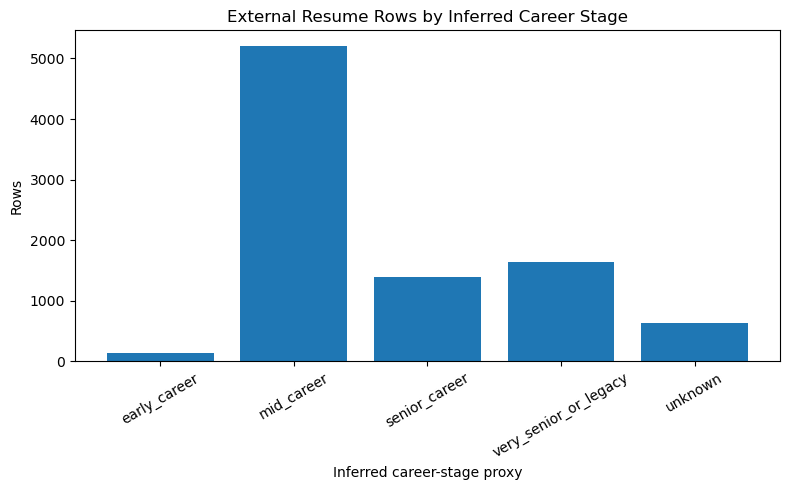

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/external_resume_rows_by_career_stage.png


In [7]:
quality_summary = pd.DataFrame({
    "metric": [
        "technical_resume_rows",
        "rows_with_stated_years_experience",
        "pct_with_stated_years_experience",
        "mean_word_count",
        "median_word_count",
    ],
    "value": [
        len(tech_df),
        tech_df["stated_years_experience"].notna().sum(),
        tech_df["stated_years_experience"].notna().mean(),
        tech_df["word_count"].mean(),
        tech_df["word_count"].median(),
    ]
})

quality_summary.to_csv(TABLES_DIR / "external_resume_quality_summary.csv", index=False)
display(quality_summary)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = career_stage_counts.copy()
plot_df["career_stage_proxy"] = pd.Categorical(
    plot_df["career_stage_proxy"].astype(str),
    categories=AGE_STAGE_ORDER,
    ordered=True,
)
plot_df = plot_df.sort_values("career_stage_proxy")
ax.bar(plot_df["career_stage_proxy"].astype(str), plot_df["rows"])
ax.set_title("External Resume Rows by Inferred Career Stage")
ax.set_xlabel("Inferred career-stage proxy")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
out = FIGURES_DIR / "external_resume_rows_by_career_stage.png"
fig.savefig(out, dpi=150)
plt.show()
print(out)

### Interpretation: External dataset composition

The external dataset is usable as a real-resume validation set, but it is not balanced by inferred career stage. Most technical resumes are classified as `mid_career`, with smaller but still meaningful groups for `senior_career` and `very_senior_or_legacy`. The `early_career` group is comparatively small, and `unknown` contains records where the available text did not provide enough reliable career-stage evidence.

Because of this imbalance, this notebook should be read as a directional robustness check rather than a controlled fairness experiment. The synthetic notebooks remain the primary controlled evidence because they have known age groups and balanced evaluation samples.


## 5. Embed external resumes

This section embeds the external resume text using the same sentence-transformer family used in the full-text synthetic experiments.

In [8]:
model = SentenceTransformer(MODEL_NAME)

external_texts = tech_df["resume_text"].fillna("").astype(str).tolist()
external_embeddings = model.encode(
    external_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)

external_embeddings.shape

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/282 [00:00<?, ?it/s]

(9000, 384)

## 6. Job-description similarity

This mirrors Notebook 07 by comparing external resumes to the job description.

In [9]:
JOB_DESCRIPTION = """
Software Engineering Manager role requiring experience with distributed systems,
cloud infrastructure, Python or Java, Kubernetes, SQL, engineering leadership,
production reliability, cross-functional collaboration, and modern software delivery practices.
""".strip()

job_embedding = model.encode([JOB_DESCRIPTION], normalize_embeddings=True)

tech_df["jobdesc_similarity"] = cosine_similarity(external_embeddings, job_embedding).ravel()
tech_df["jobdesc_similarity_percentile"] = tech_df["jobdesc_similarity"].rank(pct=True)
job_threshold = tech_df["jobdesc_similarity"].quantile(THRESHOLD_QUANTILE)
tech_df["jobdesc_screened_in"] = tech_df["jobdesc_similarity"] >= job_threshold

jobdesc_by_stage = (
    tech_df
    .groupby("career_stage_proxy", observed=True)
    .agg(
        rows=("external_resume_id", "count"),
        mean_jobdesc_similarity=("jobdesc_similarity", "mean"),
        median_jobdesc_similarity=("jobdesc_similarity", "median"),
        jobdesc_screen_rate=("jobdesc_screened_in", "mean"),
        mean_stated_years=("stated_years_experience", "mean"),
    )
    .reset_index()
)

jobdesc_by_stage.to_csv(TABLES_DIR / "external_resume_jobdesc_similarity_by_career_stage.csv", index=False)
display(jobdesc_by_stage)

,career_stage_proxy,rows,mean_jobdesc_similarity,median_jobdesc_similarity,jobdesc_screen_rate,mean_stated_years
0,early_career,130,0.381772,0.383690,0.500000,2.653846
1,mid_career,5204,0.372600,0.370755,0.440430,7.467909
2,senior_career,1392,0.387022,0.386434,0.515086,14.184631
3,very_senior_or_legacy,1642,0.379394,0.378190,0.477467,26.935897
4,unknown,632,0.338815,0.343158,0.321203,NaN


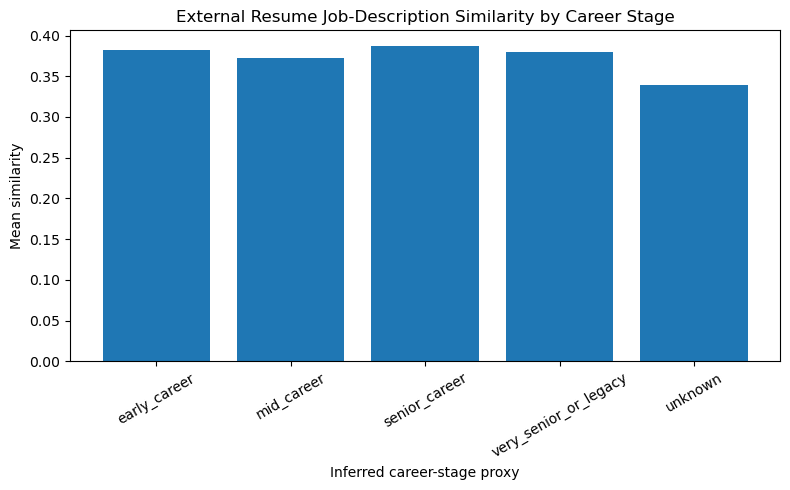

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/external_jobdesc_similarity_by_career_stage.png


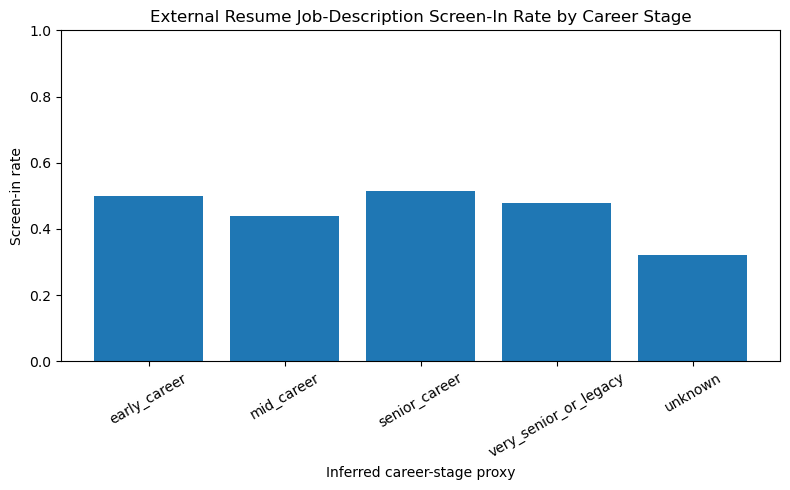

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/external_jobdesc_screen_rate_by_career_stage.png


In [10]:
plot_df = jobdesc_by_stage.copy()
plot_df["career_stage_proxy"] = pd.Categorical(
    plot_df["career_stage_proxy"].astype(str),
    categories=AGE_STAGE_ORDER,
    ordered=True,
)
plot_df = plot_df.sort_values("career_stage_proxy")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df["career_stage_proxy"].astype(str), plot_df["mean_jobdesc_similarity"])
ax.set_title("External Resume Job-Description Similarity by Career Stage")
ax.set_xlabel("Inferred career-stage proxy")
ax.set_ylabel("Mean similarity")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
out = FIGURES_DIR / "external_jobdesc_similarity_by_career_stage.png"
fig.savefig(out, dpi=150)
plt.show()
print(out)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df["career_stage_proxy"].astype(str), plot_df["jobdesc_screen_rate"])
ax.set_title("External Resume Job-Description Screen-In Rate by Career Stage")
ax.set_xlabel("Inferred career-stage proxy")
ax.set_ylabel("Screen-in rate")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
out = FIGURES_DIR / "external_jobdesc_screen_rate_by_career_stage.png"
fig.savefig(out, dpi=150)
plt.show()
print(out)

### Interpretation: Job-description similarity

The external resumes show only modest differences in mean job-description similarity across inferred career-stage groups. `senior_career`, `very_senior_or_legacy`, and `early_career` resumes all score relatively well, while the `unknown` group scores noticeably lower.

The screen-in rates show a similar pattern: resumes with clearer career-stage and technical signals are more likely to be selected than resumes in the `unknown` bucket. This suggests that the job-description similarity screen is responding to resume content that matches the software engineering manager role, not to career stage alone.

Unlike the synthetic full-text experiment, the external data does not show a clean monotonic increase with seniority. That is not surprising: the Kaggle resumes vary in quality, formatting, title conventions, and amount of usable information, and the career-stage labels are inferred rather than observed.


## 7. Load full-text reference employee resumes

This mirrors Notebook 08 by comparing external resumes to the synthetic reference employee population.

The primary reference mode is `without_direct_age_proxies`, because it removes direct date-based proxies while preserving relevant experience, title, and skills.

In [11]:
reference_path = EXPERIMENTS_DIR / f"synthetic_reference_employees_500_fulltext_{PRIMARY_MODE}.csv"
if not reference_path.exists():
    raise FileNotFoundError(
        f"Missing reference full-text file: {reference_path}. Run llm_resume_generation.py for the reference population first."
    )

reference_df = pd.read_csv(reference_path)
print(reference_df.shape)
display(reference_df[["candidate_id", "generation_mode", "age_group", "resume_text"]].head())

reference_texts = reference_df["resume_text"].fillna("").astype(str).tolist()
reference_embeddings = model.encode(
    reference_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)
reference_embeddings.shape

(500, 67)


,candidate_id,generation_mode,age_group,resume_text
0,cand_003527,without_direct_age_proxies,30-39,Taylor Thomas\n\nSummary \nExperienced softwa...
1,cand_006401,without_direct_age_proxies,40-49,Logan Patel\n\nSummary \nDetail-oriented soft...
2,cand_004217,without_direct_age_proxies,40-49,Quinn Wilson\n\nSummary \nExperienced Senior ...
3,cand_003911,without_direct_age_proxies,30-39,Quinn Nguyen\n\nSummary \nSoftware engineer w...
4,cand_000416,without_direct_age_proxies,30-39,Kai Moore\n\nSummary \nResults-driven softwar...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

(500, 384)

## 8. External resume to incumbent/reference similarity

This section computes similarity between each external resume and the synthetic reference employee resumes.

As in Notebook 08, `top10_reference_similarity` is the primary interpretation metric because it approximates a nearest-neighbor style screen while being less brittle than a single maximum match.

In [12]:
sim_matrix = cosine_similarity(external_embeddings, reference_embeddings)

tech_df["mean_reference_similarity"] = sim_matrix.mean(axis=1)
tech_df["max_reference_similarity"] = sim_matrix.max(axis=1)
tech_df["top10_reference_similarity"] = np.sort(sim_matrix, axis=1)[:, -10:].mean(axis=1)

for metric in ["mean_reference_similarity", "max_reference_similarity", "top10_reference_similarity"]:
    tech_df[f"{metric}_percentile"] = tech_df[metric].rank(pct=True)
    threshold = tech_df[metric].quantile(THRESHOLD_QUANTILE)
    tech_df[f"{metric}_screened_in"] = tech_df[metric] >= threshold

incumbent_by_stage = (
    tech_df
    .groupby("career_stage_proxy", observed=True)
    .agg(
        rows=("external_resume_id", "count"),
        mean_reference_similarity=("mean_reference_similarity", "mean"),
        max_reference_similarity=("max_reference_similarity", "mean"),
        top10_reference_similarity=("top10_reference_similarity", "mean"),
        mean_reference_screen_rate=("mean_reference_similarity_screened_in", "mean"),
        max_reference_screen_rate=("max_reference_similarity_screened_in", "mean"),
        top10_reference_screen_rate=("top10_reference_similarity_screened_in", "mean"),
    )
    .reset_index()
)

incumbent_by_stage.to_csv(TABLES_DIR / "external_resume_incumbent_similarity_by_career_stage.csv", index=False)
display(incumbent_by_stage)

,career_stage_proxy,rows,mean_reference_similarity,max_reference_similarity,top10_reference_similarity,mean_reference_screen_rate,max_reference_screen_rate,top10_reference_screen_rate
0,early_career,130,0.372171,0.502152,0.473090,0.369231,0.407692,0.400000
1,mid_career,5204,0.374507,0.503474,0.477430,0.430054,0.454458,0.452152
2,senior_career,1392,0.388358,0.509102,0.483721,0.479167,0.464080,0.447557
3,very_senior_or_legacy,1642,0.393256,0.511583,0.488234,0.530451,0.482339,0.498173
4,unknown,632,0.362125,0.475831,0.452723,0.359177,0.306962,0.322785


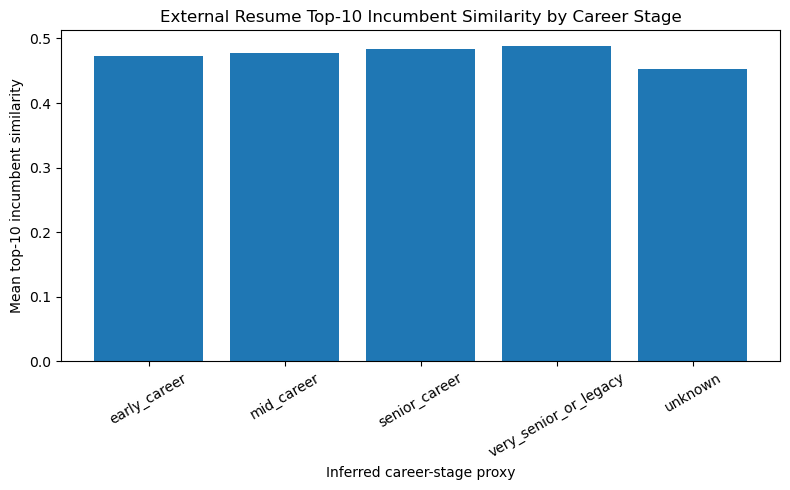

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/external_top10_incumbent_similarity_by_career_stage.png


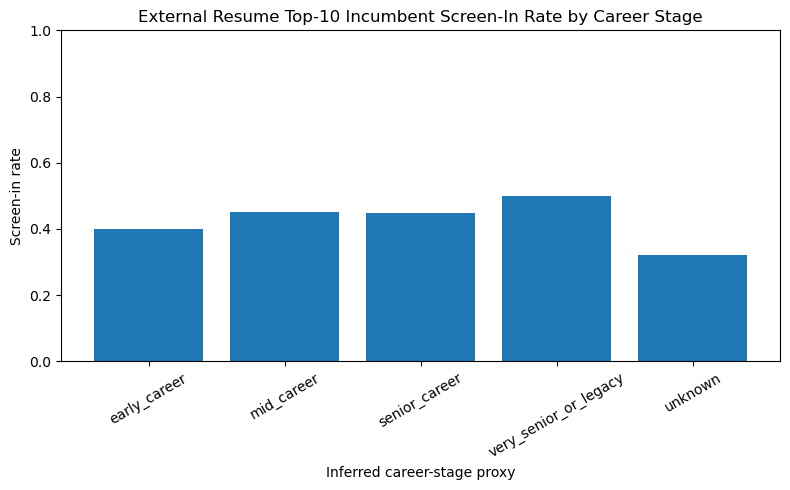

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/external_top10_incumbent_screen_rate_by_career_stage.png


In [13]:
plot_df = incumbent_by_stage.copy()
plot_df["career_stage_proxy"] = pd.Categorical(
    plot_df["career_stage_proxy"].astype(str),
    categories=AGE_STAGE_ORDER,
    ordered=True,
)
plot_df = plot_df.sort_values("career_stage_proxy")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df["career_stage_proxy"].astype(str), plot_df["top10_reference_similarity"])
ax.set_title("External Resume Top-10 Incumbent Similarity by Career Stage")
ax.set_xlabel("Inferred career-stage proxy")
ax.set_ylabel("Mean top-10 incumbent similarity")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
out = FIGURES_DIR / "external_top10_incumbent_similarity_by_career_stage.png"
fig.savefig(out, dpi=150)
plt.show()
print(out)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df["career_stage_proxy"].astype(str), plot_df["top10_reference_screen_rate"])
ax.set_title("External Resume Top-10 Incumbent Screen-In Rate by Career Stage")
ax.set_xlabel("Inferred career-stage proxy")
ax.set_ylabel("Screen-in rate")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
out = FIGURES_DIR / "external_top10_incumbent_screen_rate_by_career_stage.png"
fig.savefig(out, dpi=150)
plt.show()
print(out)

### Interpretation: Incumbent-profile similarity

The top-10 incumbent similarity scores are tightly clustered across career-stage groups. This means many external technical resumes look broadly similar to at least some resumes in the synthetic reference population, even when the inferred career-stage label differs.

The `very_senior_or_legacy` group has the highest top-10 incumbent similarity and the highest incumbent-profile screen-in rate in this run, while the `unknown` group is lowest. This does not mean very senior candidates are universally preferred by incumbent-profile screening. It more likely reflects the composition of this external dataset: many very senior or legacy-labeled resumes are enterprise software resumes with Java/J2EE, architecture, and systems experience that overlap semantically with the synthetic reference employee resumes.

This result is useful because it shows pipeline portability, but it is weaker as fairness evidence than the synthetic experiments. The external dataset lacks true age labels and does not provide a controlled candidate distribution.


## 9. Compare job-description and incumbent-profile screening

This section compares relative standing under the two screening targets. It uses percentiles and screen-in flags rather than subtracting raw cosine similarities, because job-description similarity and incumbent-profile similarity have different score distributions.

In [14]:
tech_df["jobdesc_minus_incumbent_percentile"] = (
    tech_df["jobdesc_similarity_percentile"] - tech_df["top10_reference_similarity_percentile"]
)

tech_df["screening_outcome"] = np.select(
    [
        tech_df["jobdesc_screened_in"] & tech_df["top10_reference_similarity_screened_in"],
        tech_df["jobdesc_screened_in"] & ~tech_df["top10_reference_similarity_screened_in"],
        ~tech_df["jobdesc_screened_in"] & tech_df["top10_reference_similarity_screened_in"],
    ],
    [
        "screened_by_both",
        "jobdesc_only",
        "incumbent_only",
    ],
    default="screened_by_neither",
)

comparison_by_stage = (
    tech_df
    .groupby("career_stage_proxy", observed=True)
    .agg(
        rows=("external_resume_id", "count"),
        mean_jobdesc_percentile=("jobdesc_similarity_percentile", "mean"),
        mean_incumbent_percentile=("top10_reference_similarity_percentile", "mean"),
        mean_jobdesc_minus_incumbent_percentile=("jobdesc_minus_incumbent_percentile", "mean"),
        jobdesc_screen_rate=("jobdesc_screened_in", "mean"),
        incumbent_screen_rate=("top10_reference_similarity_screened_in", "mean"),
    )
    .reset_index()
)

outcome_mix_by_stage = (
    tech_df
    .groupby(["career_stage_proxy", "screening_outcome"], observed=True)
    .size()
    .reset_index(name="rows")
)
outcome_mix_by_stage["share"] = (
    outcome_mix_by_stage["rows"]
    / outcome_mix_by_stage.groupby("career_stage_proxy", observed=True)["rows"].transform("sum")
)

comparison_by_stage.to_csv(TABLES_DIR / "external_resume_jobdesc_vs_incumbent_by_career_stage.csv", index=False)
outcome_mix_by_stage.to_csv(TABLES_DIR / "external_resume_screening_outcome_mix_by_career_stage.csv", index=False)

display(comparison_by_stage)
display(outcome_mix_by_stage)

,career_stage_proxy,rows,mean_jobdesc_percentile,mean_incumbent_percentile,mean_jobdesc_minus_incumbent_percentile,jobdesc_screen_rate,incumbent_screen_rate
0,early_career,130,0.526312,0.470624,0.055688,0.500000,0.400000
1,mid_career,5204,0.495065,0.496901,-0.001836,0.440430,0.452152
2,senior_career,1392,0.547088,0.514987,0.032101,0.515086,0.447557
3,very_senior_or_legacy,1642,0.516782,0.536419,-0.019637,0.477467,0.498173
4,unknown,632,0.388696,0.404721,-0.016025,0.321203,0.322785


,career_stage_proxy,screening_outcome,rows,share
0,early_career,incumbent_only,6,0.046154
1,early_career,jobdesc_only,19,0.146154
2,early_career,screened_by_both,46,0.353846
3,early_career,screened_by_neither,59,0.453846
4,mid_career,incumbent_only,468,0.089931
5,mid_career,jobdesc_only,407,0.078209
6,mid_career,screened_by_both,1885,0.362221
7,mid_career,screened_by_neither,2444,0.469639
8,senior_career,incumbent_only,88,0.063218
9,senior_career,jobdesc_only,182,0.130747


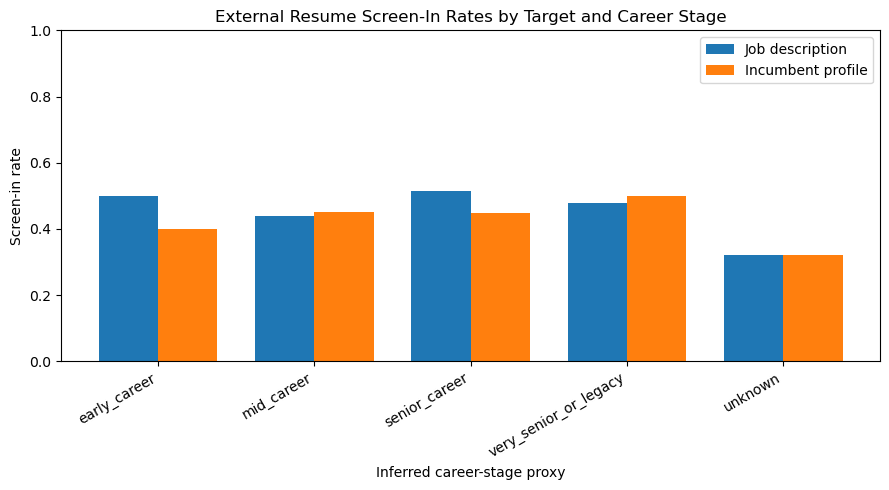

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/external_jobdesc_vs_incumbent_screen_rates_by_career_stage.png


In [15]:
plot_df = comparison_by_stage.copy()
plot_df["career_stage_proxy"] = pd.Categorical(
    plot_df["career_stage_proxy"].astype(str),
    categories=AGE_STAGE_ORDER,
    ordered=True,
)
plot_df = plot_df.sort_values("career_stage_proxy")

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, plot_df["jobdesc_screen_rate"], width, label="Job description")
ax.bar(x + width/2, plot_df["incumbent_screen_rate"], width, label="Incumbent profile")
ax.set_title("External Resume Screen-In Rates by Target and Career Stage")
ax.set_xlabel("Inferred career-stage proxy")
ax.set_ylabel("Screen-in rate")
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["career_stage_proxy"].astype(str), rotation=30, ha="right")
ax.legend()
fig.tight_layout()
out = FIGURES_DIR / "external_jobdesc_vs_incumbent_screen_rates_by_career_stage.png"
fig.savefig(out, dpi=150)
plt.show()
print(out)

## 10. Interpretation

This external validation notebook should be interpreted carefully. The Kaggle dataset provides real resume text, but it does not provide true age labels. The analysis therefore uses inferred career-stage proxies rather than protected attributes.

The main result is that the external data produces a weaker and less clean pattern than the synthetic experiments. Job-description similarity does not simply increase with inferred career stage, and incumbent-profile similarity does not clearly penalize the most senior group. Instead, the strongest contrast is between resumes with clear technical/career-stage signals and the `unknown` group, which tends to score lower and screen in less often.

The `very_senior_or_legacy` group performs relatively well against the incumbent-profile target in this dataset. That differs from the controlled synthetic mechanism in Notebook 08, where the incumbent-profile screen favored candidates closest to the mid-career reference population. This difference is plausible because the external dataset appears to contain many enterprise software resumes whose terminology overlaps strongly with the synthetic reference population, especially Java/J2EE, architecture, and systems-oriented language.

This does not invalidate the synthetic results. Rather, it clarifies the role of Notebook 09: it is a pipeline portability and directional robustness check, not a definitive age-bias measurement. The external dataset is useful because it demonstrates that the same job-description and incumbent-profile comparison framework can be applied to real resume text. However, because career stage is inferred, group sizes are imbalanced, and the dataset is concentrated in technical resume categories with overlapping vocabulary, the results should be presented as supplementary evidence.

The strongest conclusion from Notebook 09 is therefore limited but useful: real resume text can be parsed into career-stage proxies and evaluated under the same two-target framework used in the synthetic experiments. The external results are mixed, which reinforces why the controlled synthetic experiments are necessary for isolating the mechanism.


## 11. Save scored external dataset

In [16]:
scored_external_path = EXPERIMENTS_DIR / "external_resume_career_stage_scored.parquet"
tech_df.to_parquet(scored_external_path, index=False)
print(scored_external_path)

csv_path = EXPERIMENTS_DIR / "external_resume_career_stage_scored.csv"
tech_df.to_csv(csv_path, index=False)
print(csv_path)

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/data/experiments/external_resume_career_stage_scored.parquet
/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/data/experiments/external_resume_career_stage_scored.csv
